# Potential Methods for Regression Analysis

thinking this flow: 
- histograms for all variables to assess normal distribution
- correlation matrix to assess collinearity
- fitting regression models --> predicting heat from explanatory variables

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
import numpy as np
from numpy import log
import seaborn as sns

In [2]:
block_data_raw = pd.read_csv("NYC_block_combined_data.csv")

In [3]:
block_data_raw

,Unnamed: 0,GISJOIN,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,NAME20,MTFCC20,UR20,...,Shape_Area,geometry,borough,total_pop,mean_dist_to_park,min_dist_to_park,mean_dist_to_water,min_dist_to_water,mean_dist_to_buildings,min_dist_to_buildings
0,0,G36000500001001000,36,5,100,1000,360050001001000,Block 1000,G5040,NaN,...,469092.698143,"POLYGON ((594050.2095392216 4515675.115395387,...",Bronx,171,1536.397529,700.000000,164.297023,100.000000,292.242460,0.000000
1,1,G36000500001001001,36,5,100,1001,360050001001001,Block 1001,G5040,NaN,...,518008.039135,"POLYGON ((594129.2942939431 4515899.617578963,...",Bronx,1344,1405.743466,1004.987549,287.243928,100.000000,116.649964,0.000000
2,2,G36000500001001002,36,5,100,1002,360050001001002,Block 1002,G5040,NaN,...,13147.826480,"POLYGON ((594137.1991438607 4516571.541309851,...",Bronx,367,NaN,NaN,NaN,NaN,NaN,NaN
3,3,G36000500001001003,36,5,100,1003,360050001001003,Block 1003,G5040,NaN,...,676961.813449,"POLYGON ((594128.3043432559 4516594.188586152,...",Bronx,1890,757.859258,300.000000,233.194423,0.000000,96.086870,0.000000
4,4,G36000500002001000,36,5,200,1000,360050002001000,Block 1000,G5040,NaN,...,19130.472390,POLYGON ((596181.6307349342 4518858.9206029065...,Bronx,310,299.690165,282.842712,500.000000,400.000000,66.666667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37475,37475,G36008500323001021,36,85,32300,1021,360850323001021,Block 1021,G5040,NaN,...,37948.170428,"POLYGON ((569795.6771551144 4497546.276157519,...",Staten Island,11,153.005640,100.000000,214.295532,141.421356,348.953223,300.000000
37476,37476,G36008500323001022,36,85,32300,1022,360850323001022,Block 1022,G5040,NaN,...,303220.113276,"POLYGON ((570487.3090163402 4497726.420084525,...",Staten Island,33,265.503468,0.000000,140.714347,0.000000,242.517022,0.000000
37477,37477,G36008500323001023,36,85,32300,1023,360850323001023,Block 1023,G5040,NaN,...,3771.331525,"POLYGON ((569795.6771551144 4497546.276157519,...",Staten Island,0,NaN,NaN,NaN,NaN,NaN,NaN
37478,37478,G36008500323001024,36,85,32300,1024,360850323001024,Block 1024,G5040,NaN,...,6654.695826,"POLYGON ((569616.0107518218 4497502.075250244,...",Staten Island,0,0.000000,0.000000,100.000000,100.000000,141.421356,141.421356


In [4]:
block_data_cols = [
    "total_pop",
    "mean_dist_to_park",
    "mean_dist_to_water",
    "mean_dist_to_buildings",
]

block_data = block_data_raw[block_data_cols]

In [5]:
block_data

,total_pop,mean_dist_to_park,mean_dist_to_water,mean_dist_to_buildings
0,171,1536.397529,164.297023,292.242460
1,1344,1405.743466,287.243928,116.649964
2,367,NaN,NaN,NaN
3,1890,757.859258,233.194423,96.086870
4,310,299.690165,500.000000,66.666667
...,...,...,...,...
37475,11,153.005640,214.295532,348.953223
37476,33,265.503468,140.714347,242.517022
37477,0,NaN,NaN,NaN
37478,0,0.000000,100.000000,141.421356


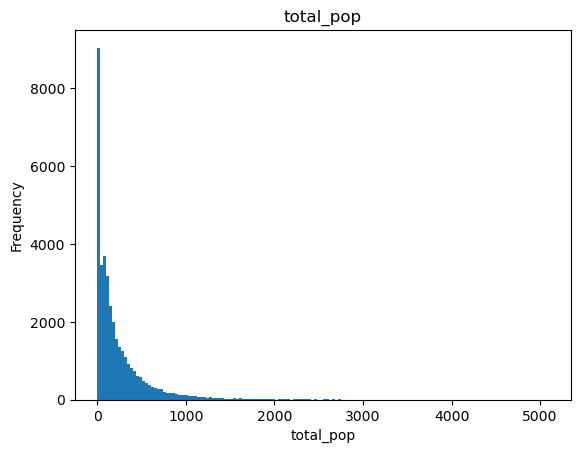

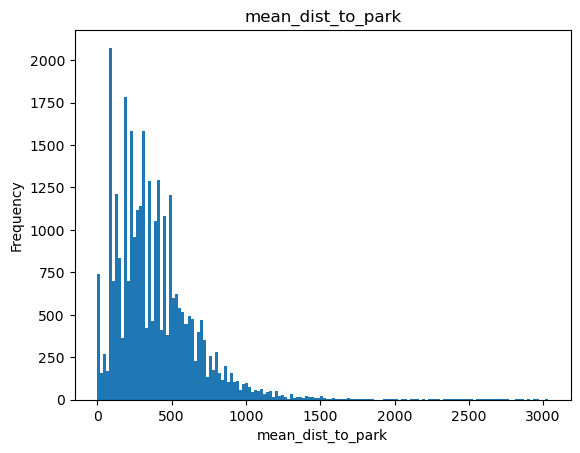

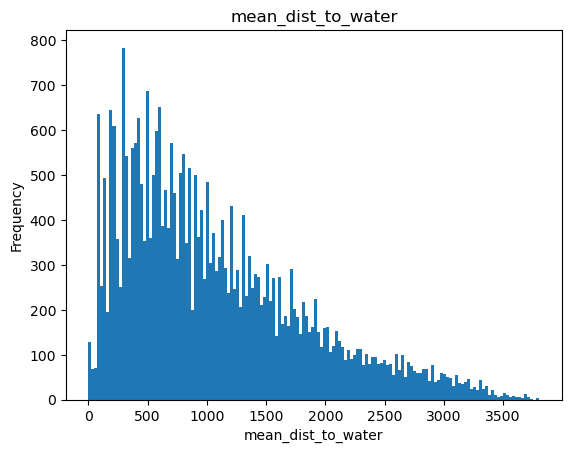

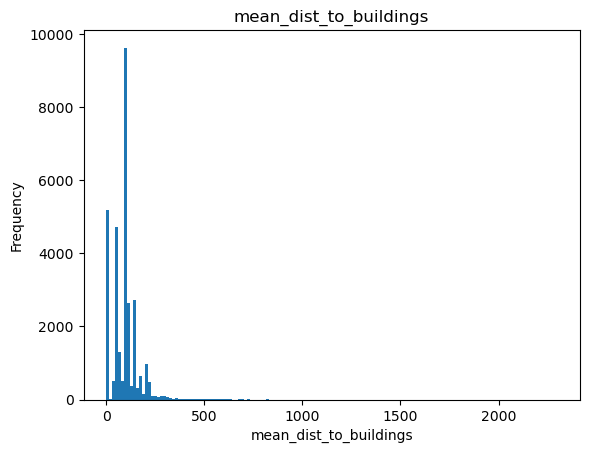

In [6]:
for col in block_data.columns:
    plt.figure()
    block_data[col].plot(kind="hist", bins=150, title=col)
    plt.xlabel(col)
    plt.show()

it seems like many of the histograms have a strong left skew, will attempt to log transform and see if that helps the variables

In [8]:
log_block_data = block_data.copy()

for col in log_block_data.columns:
    log_block_data[col] = log(log_block_data[col])

c:\Users\gutgi\miniforge3\envs\geo_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
log_block_data

,total_pop,mean_dist_to_park,mean_dist_to_water,mean_dist_to_buildings
0,5.141664,7.337196,5.101676,5.677584
1,7.203406,7.248322,5.660332,4.759178
2,5.905362,NaN,NaN,NaN
3,7.544332,6.630498,5.451873,4.565253
4,5.736572,5.702749,6.214608,4.199705
...,...,...,...,...
37475,2.397895,5.030475,5.367356,5.854938
37476,3.496508,5.581628,4.946732,5.491072
37477,-inf,NaN,NaN,NaN
37478,-inf,-inf,4.605170,4.951744


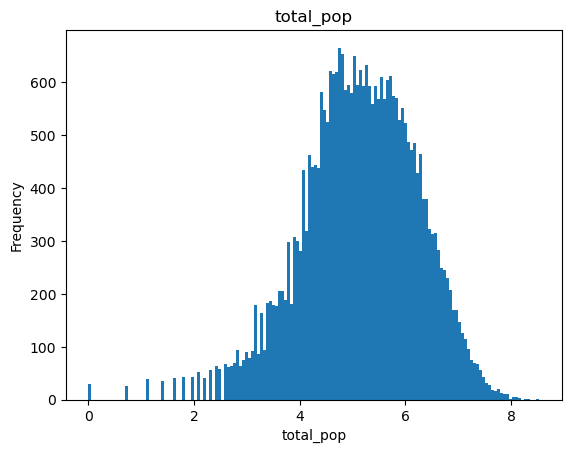

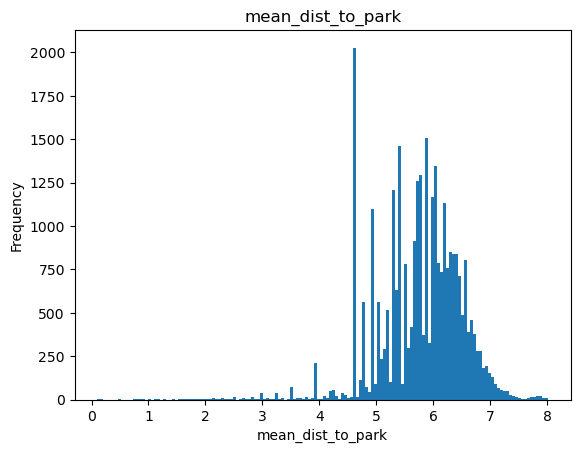

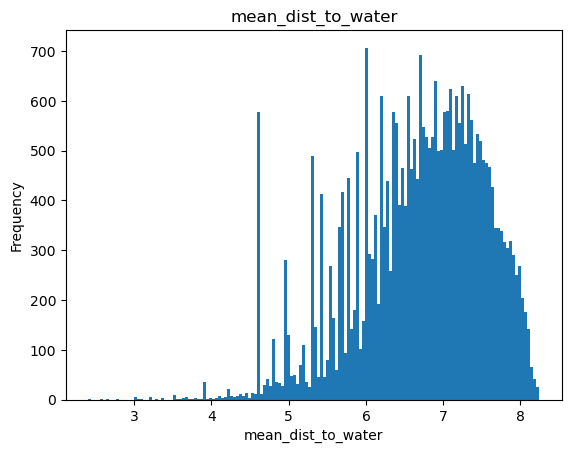

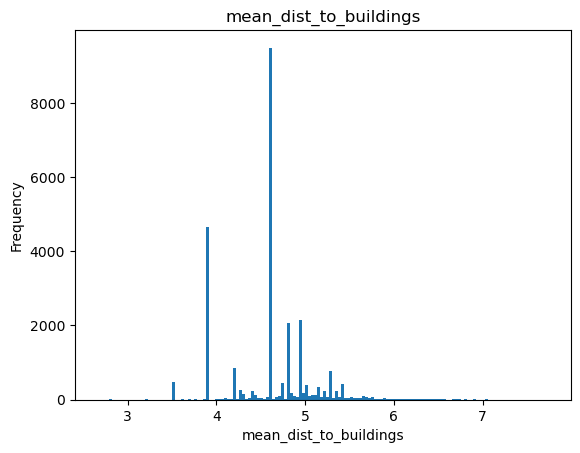

In [10]:
log_block_data.replace(-np.inf, np.nan, inplace=True)

for col in log_block_data.columns:
    plt.figure()
    log_block_data[col].plot(kind="hist", bins=150, title=col)
    plt.xlabel(col)
    plt.show()

Correlation matrix is : 


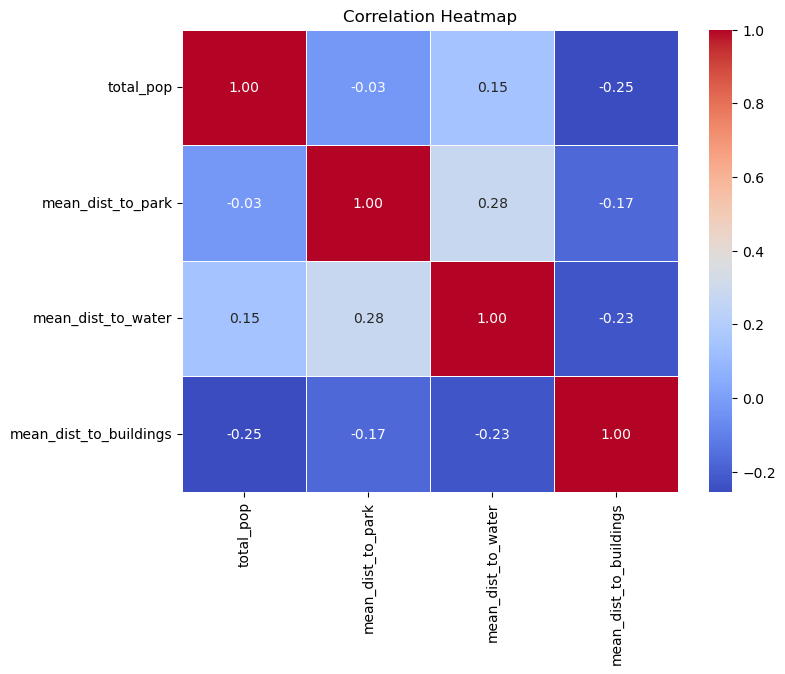

In [13]:
matrix = log_block_data.corr()
print("Correlation matrix is : ")

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

none of the variables thus far seem very correlated!